# 

### Datasets:

Tashkent Food Prices Prediction with ML



Overview: While reviewing my ML skills, I have got an idea to train a ML model to predict common food products in different parts of the Tashkent, the Capital of Uzbekistan. I have tried to combine multiple datasets by extracting possible correlated features to achieve best prediction outcome. Challenging phase was Data Collection because of shortage of datasets, different data formats and data quality issues.




    

In [22]:
from pathlib import Path
import pandas as pd
import json
import urllib.request
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [23]:
## data loading function 
def load_food_data():
    
    data_path = Path("datasets")
    if not (data_path / "prices.csv").exists():
        # Define the URL and the path to save the data
        url = "https://opendata-back.tashkent.uz/en/api/data/all/30/download"

        # Create the directory if it doesn't exist
        data_path.mkdir(parents=True, exist_ok=True)

        food_json_str = urllib.request.urlopen(url).read().decode('utf-8')
        food_json = json.loads(food_json_str)
        
        rows = []

        for year, months in food_json["data"].items():
            for month, products in months.items():
                for product, districts in products.items():
                    for district, price in districts.items():
                        rows.append({
                            "year": year,
                            "month": month,
                            "product": product,
                            "district": district,
                            "price": price
                        })

        print(f"Loaded {len(rows)} rows of food price data.")
        fp_df = pd.DataFrame(rows)

        fp_df.to_csv(data_path / "prices.csv", index=False, encoding="utf-8-sig")
    
    else:
        print("Data already exists. Loading from CSV.")
   
    csv_path = data_path / "prices.csv"
    return pd.read_csv(csv_path)

In [24]:
df = load_food_data()

Data already exists. Loading from CSV.


In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34099 entries, 0 to 34098
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   year      34099 non-null  int64  
 1   month     34099 non-null  str    
 2   product   34099 non-null  str    
 3   district  34099 non-null  str    
 4   price     33607 non-null  float64
dtypes: float64(1), int64(1), str(3)
memory usage: 1.3 MB


In [26]:
month_map = {
    "yanvar": 1,
    "fevral": 2,
    "mart": 3,
    "aprel": 4,
    "may": 5,
    "iyun": 6,
    "iyul": 7,
    "avgust": 8,
    "sentabr": 9,
    "oktabr": 10,
    "noyabr": 11,
    "dekabr": 12
}

df["month_num"] = df["month"].map(month_map)

df["date"] = pd.to_datetime({
    "year": df["year"],
    "month": df["month_num"],
    "day": 1
})

In [27]:
print("Mahsulot turlari soni:", len(df["product"].unique()), "ta")
print("Tumanlar soni:", len(df["district"].unique()), "ta")

Mahsulot turlari soni: 71 ta
Tumanlar soni: 13 ta


In [28]:
encoder = OrdinalEncoder()
df[["month", "product", "district"]] = encoder.fit_transform(df[["month", "product", "district"]])

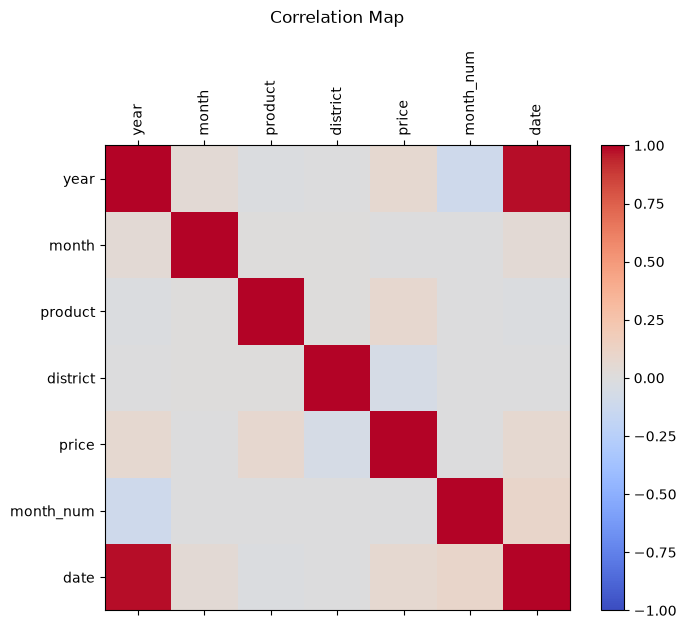

In [29]:
def corr_graph(df):
    # 1. Calculate the correlation matrix
    corr_matrix = df.corr()

    # 2. Set up the Matplotlib figure
    fig = plt.figure(figsize=(8, 6))

    # 3. Create the correlation map
    cax = plt.matshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, fignum=fig.number)

    # 4. Add axis labels and ticks
    plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
    plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

    # 5. Add a colorbar to show the scale
    plt.colorbar(cax)

    plt.title('Correlation Map', pad=20)
    plt.show()
    
    
corr_graph(df)


### As you can see there is no good correlation in between any of features, thats why lets see crrelation between products themselves

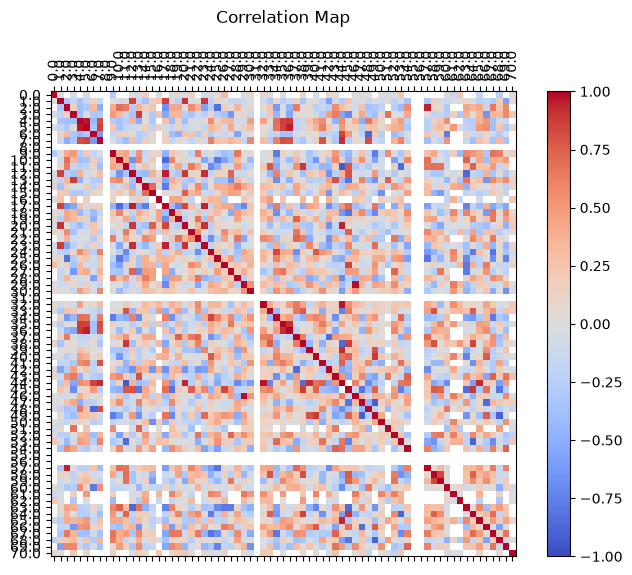

In [30]:
pivot = df.pivot_table(
    index="date",
    columns="product",
    values="price"
)

corr_graph(pivot.diff())

In [31]:
df.dropna(inplace=True)

<Axes: >

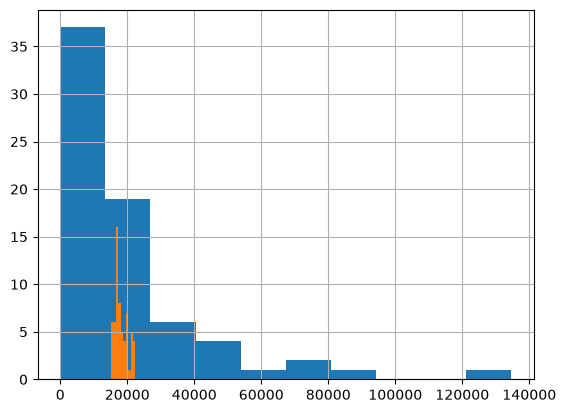

In [32]:
df.groupby('product')["price"].mean().hist()
df.groupby('date')["price"].mean().hist()

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    df[["month", "product", "district"]],
    df["price"],
    test_size=0.2,
    random_state=42
)

In [ ]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_pred = linear_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R^2 Score:", r2)

print("Completely trash!!!")

Mean Squared Error: 577995558.4445134
R^2 Score: 0.009266781128101198
Completely trash!!!


## Fuel Prices  

In [46]:
from utils.fuel_scrap import scrape_fuel_year

# Pull every available year and stack them into one DataFrame.
YEARS = [2021, 2022, 2023, 2024, 2025, 2026]
fuel = pd.concat([scrape_fuel_year(y) for y in YEARS], ignore_index=True)

# Prices arrive as strings ("12 800") with "-" for missing -> convert to numbers.
price_cols = [c for c in fuel.columns if c not in ("Gas station name", "date")]
for c in price_cols:
    fuel[c] = pd.to_numeric(
        fuel[c].astype(str).str.replace(r"[^0-9]", "", regex=True).replace("", pd.NA),
        errors="coerce",
    )

print(f"{fuel['date'].nunique()} snapshots, {len(fuel)} rows")
print("Date range:", fuel["date"].min().date(), "->", fuel["date"].max().date())
fuel.head()

141 snapshots, 4321 rows
Date range: 2021-02-01 -> 2026-07-06


,Gas station name,AI-80,AI-92 UZB,AI-92 IMPORT,AI-95,AI-98,AI-100,Diesel,date
0,"Carvon (former UNG, Uzbekneftegaz, Uzgazoil)",6500.0,NaN,9600.0,10300.0,NaN,NaN,9500.0,2021-12-25
1,MUSTANG,7500.0,NaN,9700.0,10500.0,NaN,NaN,9500.0,2021-12-25
2,INTRANS SERVIS,7400.0,NaN,9900.0,10400.0,NaN,NaN,NaN,2021-12-25
3,POYTAHT OIL,7200.0,NaN,9600.0,10500.0,NaN,NaN,NaN,2021-12-25
4,IBR,7200.0,NaN,9600.0,10300.0,NaN,NaN,NaN,2021-12-25


In [47]:
# Average all stations into one row per month.
# Drop "Gas station name" (not needed) and "AI-92 UZB" (empty for 2024).
fuel_monthly = (
    fuel.drop(columns=["Gas station name", "AI-92 UZB"])
        .assign(date=lambda d: d["date"].dt.to_period("M").dt.to_timestamp())
        .groupby("date")
        .mean(numeric_only=True)
        .round(0)
        .reset_index()
)

fuel_monthly.head()

,date,AI-80,AI-92 IMPORT,AI-95,AI-98,AI-100,Diesel
0,2021-02-01,5311.0,6179.0,6977.0,NaN,NaN,6382.0
1,2021-03-01,5444.0,6371.0,7068.0,NaN,NaN,6546.0
2,2021-04-01,5484.0,6524.0,7100.0,NaN,NaN,6617.0
3,2021-05-01,5651.0,6903.0,7417.0,NaN,NaN,6833.0
4,2021-06-01,5823.0,7133.0,7640.0,NaN,NaN,7281.0


In [48]:
fuel_monthly["date"] = pd.to_datetime(fuel_monthly["date"])

full_dates = pd.date_range(
    start="2021-01-01",
    end=fuel_monthly["date"].max(),
    freq="MS"      # Month Start
)

fuel_monthly = (
    fuel_monthly.set_index("date")
      .reindex(full_dates)
      .rename_axis("date")
      .reset_index()
)

In [57]:
cols = ["AI-80", "AI-98", "AI-100"]

fuel_monthly[cols] = (
    fuel_monthly[cols]
    .interpolate(method="linear")
    .bfill()
    .ffill()
)

In [51]:
fuel_monthly

,date,AI-80,AI-92 IMPORT,AI-95,AI-98,AI-100,Diesel
0,2021-01-01,5311.0,NaN,NaN,12441.0,12292.0,NaN
1,2021-02-01,5311.0,6179.0,6977.0,12441.0,12292.0,6382.0
2,2021-03-01,5444.0,6371.0,7068.0,12441.0,12292.0,6546.0
3,2021-04-01,5484.0,6524.0,7100.0,12441.0,12292.0,6617.0
4,2021-05-01,5651.0,6903.0,7417.0,12441.0,12292.0,6833.0
...,...,...,...,...,...,...,...
62,2026-03-01,8950.0,11446.0,13195.0,16887.0,18696.0,12363.0
63,2026-04-01,8950.0,11731.0,13421.0,17019.0,18793.0,12357.0
64,2026-05-01,8950.0,11806.0,13528.0,16996.0,18936.0,12393.0
65,2026-06-01,8950.0,12537.0,14507.0,17715.0,19819.0,13032.0


In [52]:
fuel_monthly.info()

<class 'pandas.DataFrame'>
RangeIndex: 67 entries, 0 to 66
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          67 non-null     datetime64[us]
 1   AI-80         67 non-null     float64       
 2   AI-92 IMPORT  61 non-null     float64       
 3   AI-95         61 non-null     float64       
 4   AI-98         67 non-null     float64       
 5   AI-100        67 non-null     float64       
 6   Diesel        61 non-null     float64       
dtypes: datetime64[us](1), float64(6)
memory usage: 3.8 KB


## Merge food price and fuel dataframes

In [58]:
merged_df = pd.merge(fuel_monthly, df.drop(columns=['year', 'month']), on="date", how="outer")

In [62]:
cols = ["AI-80", "AI-98", "AI-100"]

merged_df[cols] = (
    merged_df[cols]
    .interpolate(method="linear")
    .bfill()
    .ffill()
)

merged_df.dropna(inplace=True)

array([[<Axes: title={'center': 'AI-80'}>,
        <Axes: title={'center': 'AI-92 IMPORT'}>,
        <Axes: title={'center': 'AI-95'}>],
       [<Axes: title={'center': 'AI-98'}>,
        <Axes: title={'center': 'AI-100'}>,
        <Axes: title={'center': 'Diesel'}>],
       [<Axes: title={'center': 'product'}>,
        <Axes: title={'center': 'district'}>,
        <Axes: title={'center': 'price'}>]], dtype=object)

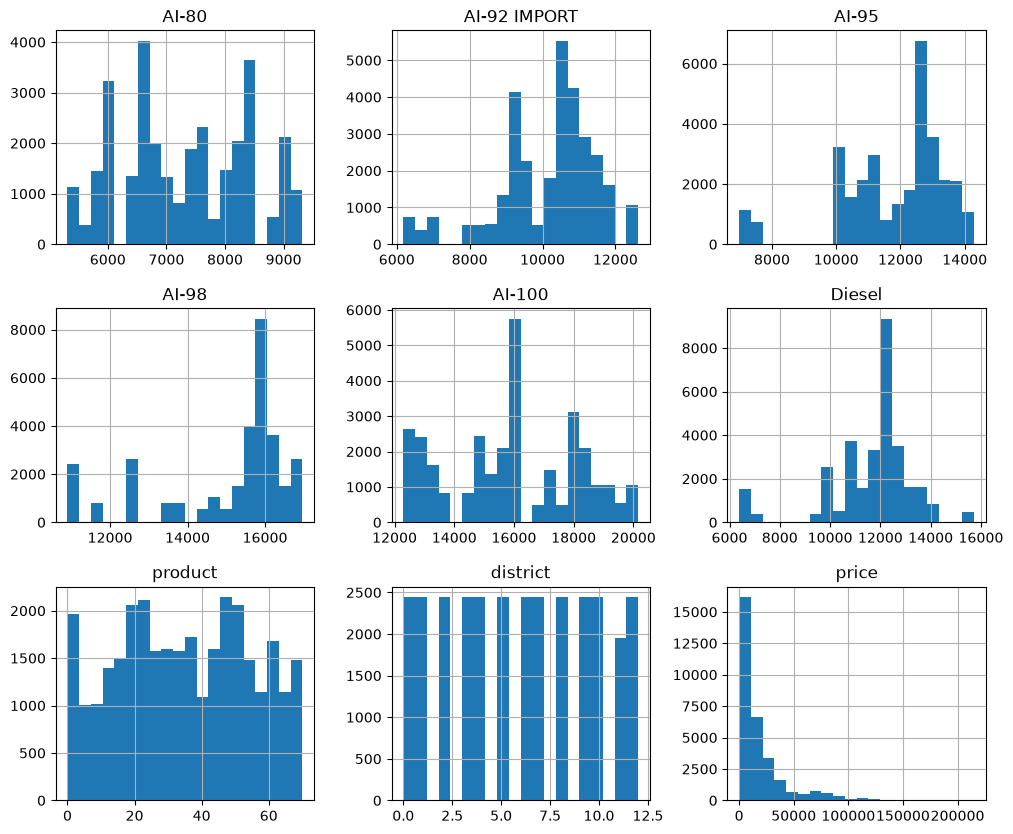

In [ ]:
merged_df.select_dtypes("number").hist(figsize=(12, 10), bins=20)


In [73]:
merged_df.head()

,date,AI-80,AI-92 IMPORT,AI-95,AI-98,AI-100,Diesel,product,district,price
377,2021-02-01,5311.0,6179.0,6977.0,12441.0,12292.0,6382.0,2.0,0.0,21900.000000
378,2021-02-01,5311.0,6179.0,6977.0,12441.0,12292.0,6382.0,2.0,2.0,31125.000000
379,2021-02-01,5311.0,6179.0,6977.0,12441.0,12292.0,6382.0,2.0,9.0,20416.666675
380,2021-02-01,5311.0,6179.0,6977.0,12441.0,12292.0,6382.0,2.0,10.0,0.000000
381,2021-02-01,5311.0,6179.0,6977.0,12441.0,12292.0,6382.0,2.0,1.0,24125.000000


In [75]:
num_cols = [
    "AI-80", "AI-92 IMPORT", "AI-95",
    "AI-98", "AI-100", "Diesel", "price"
]

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
merged_df[num_cols] = scaler.fit_transform(merged_df[num_cols])

In [76]:
merged_df.head()

,date,AI-80,AI-92 IMPORT,AI-95,AI-98,AI-100,Diesel,product,district,price
377,2021-02-01,0.0,0.0,0.0,0.254207,0.0,0.0,2.0,0.0,0.101829
378,2021-02-01,0.0,0.0,0.0,0.254207,0.0,0.0,2.0,2.0,0.144722
379,2021-02-01,0.0,0.0,0.0,0.254207,0.0,0.0,2.0,9.0,0.094932
380,2021-02-01,0.0,0.0,0.0,0.254207,0.0,0.0,2.0,10.0,0.000000
381,2021-02-01,0.0,0.0,0.0,0.254207,0.0,0.0,2.0,1.0,0.112174


In [ ]:
train = merged_df[merged_df.date < "2024-02-01"]
test = merged_df[merged_df.date >= "2024-01-01"]



X_train = merged_df.drop(columns=["price", "date"])
y_train = merged_df["price"]

X_test = test.drop(columns=["price", "date"])
y_test = test["price"]


linear_model = LinearRegression()
linear_model.fit(X_train, y_train)


y_pred = linear_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R^2 Score:", r2)



print("Completely trash!!!")

Mean Squared Error: 0.01472034120302681
R^2 Score: 0.01838538292176295
Completely trash!!!


In [ ]:
encoder = OneHotEncoder(sparse_output=False, drop="first")
X_train[['product']] = encoder.fit_transform(X_train[['product']])
X_train[['district']] = encoder.fit_transform(X_train[['district']])
X_test[['product']] = encoder.fit_transform(X_test[['product']])
X_test[['district']] = encoder.fit_transform(X_test[['district']])

In [ ]:
from sklearn.ensemble import RandomForestRegressor



random_forest_model = RandomForestRegressor(n_estimators=100, random_state=42)
random_forest_model.fit(X_train, y_train)

y_pred = random_forest_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R^2 Score:", r2)



Mean Squared Error: 0.012841818389339324
R^2 Score: 0.015153338047871667
